# 03a — Elevation-Stratified Resampling (v2)

Fixes geographic confounding by generating negatives that span the **same elevation distribution** as fire points.

**Key changes vs v1:**
- Buffer reduced: 5 km → 1 km
- Joint stratification: elevation band × land cover class
- Negatives now appear *inside* the Sierras de Córdoba, not just on the flat plains

**Outputs:**
- `data/processed/sample_points_v2.gpkg`
- `data/processed/dataset_v2.csv`

In [1]:
import sys
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import shapely
from scipy.spatial import cKDTree
from scipy.stats import ks_2samp
from shapely.geometry import Point
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
matplotlib.rcParams['figure.dpi'] = 120

ROOT      = Path('..').resolve()
RAW       = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed'
OUTPUTS   = ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)

CRS_WGS84  = 'EPSG:4326'
CRS_METRIC = 'EPSG:32720'  # UTM Zone 20S

GRID_SIZE_M   = 500       # 500m dedup grid (matches MODIS)
NEG_BUFFER_M  = 1_000     # 1km exclusion buffer (was 5km in v1)
BATCH_SIZE    = 150_000
OVERSAMPLE    = 6         # Generate 6× candidates for stratification
RANDOM_SEED   = 42
N_ELEV_BANDS  = 5

print('Setup complete.')

Setup complete.


## 1. Load Boundary & Fire Points — Deduplicate

In [2]:
# Load Córdoba boundary
boundary_gdf = gpd.read_file(RAW / 'cordoba_boundary.shp').to_crs(CRS_WGS84)
boundary_poly = boundary_gdf.geometry.union_all()
bbox = boundary_poly.bounds
minx, miny, maxx, maxy = bbox
print(f'Boundary bbox: {bbox}')

# Load raw MODIS fire detections
fire_raw = gpd.read_file(PROCESSED / 'firms_modis.gpkg').to_crs(CRS_WGS84)
print(f'Raw MODIS detections: {len(fire_raw):,}')

# Deduplicate to 500m UTM grid (same logic as sampling.py)
fire_utm = fire_raw.to_crs(CRS_METRIC)
easting  = fire_utm.geometry.x.values
northing = fire_utm.geometry.y.values
cell_x   = (easting  // GRID_SIZE_M).astype(np.int64)
cell_y   = (northing // GRID_SIZE_M).astype(np.int64)

df_grid = pd.DataFrame({
    'cell_x': cell_x, 'cell_y': cell_y,
    'easting': easting, 'northing': northing,
    'date': fire_raw['date'].values,
})
dedup = (
    df_grid.groupby(['cell_x', 'cell_y'])
    .agg(easting=('easting', 'mean'), northing=('northing', 'mean'), date=('date', 'first'))
    .reset_index(drop=True)
)

geom_utm = [Point(e, n) for e, n in zip(dedup.easting, dedup.northing)]
pos_utm  = gpd.GeoDataFrame({'date': dedup.date}, geometry=geom_utm, crs=CRS_METRIC)
pos_gdf  = pos_utm.to_crs(CRS_WGS84)
pos_gdf['label'] = 1
pos_gdf['lat']   = pos_gdf.geometry.y
pos_gdf['lon']   = pos_gdf.geometry.x
pos_gdf['month'] = pd.to_datetime(pos_gdf['date']).dt.month.astype('Int64')
pos_gdf = pos_gdf.reset_index(drop=True)

n_positive = len(pos_gdf)
print(f'After 500m grid dedup: {n_positive:,} unique fire cells')

Boundary bbox: (-65.7782592779999, -34.99873351899993, -61.77767181399997, -29.503320692999978)


Raw MODIS detections: 45,313


After 500m grid dedup: 36,148 unique fire cells


## 2. Extract Fire-Point Elevations & Define Bands

Fire elevation — min: 67m  median: 263m  max: 2670m
NaN elevations: 0


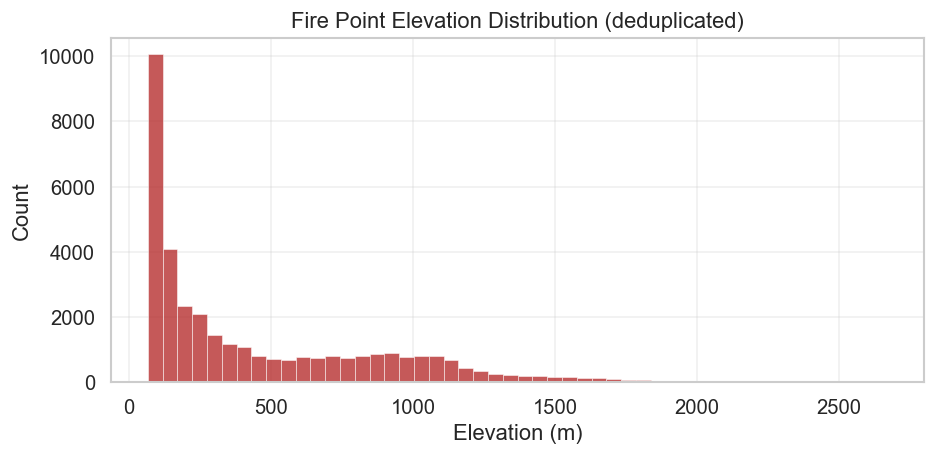

In [3]:
# Extract elevation at deduplicated fire points
dem_path = RAW / 'dem' / 'elevation.tif'
with rasterio.open(dem_path) as src:
    dem_nodata = src.nodata
    elev_fire  = np.array([v[0] for v in src.sample(zip(pos_gdf.lon, pos_gdf.lat))], dtype=float)

if dem_nodata is not None:
    elev_fire[elev_fire == dem_nodata] = np.nan
elev_fire[elev_fire <= -9000] = np.nan

valid_elev = elev_fire[~np.isnan(elev_fire)]
print(f'Fire elevation — min: {valid_elev.min():.0f}m  '
      f'median: {np.median(valid_elev):.0f}m  max: {valid_elev.max():.0f}m')
print(f'NaN elevations: {np.isnan(elev_fire).sum()}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(valid_elev, bins=50, color='firebrick', alpha=0.75, edgecolor='white', linewidth=0.4)
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Count')
ax.set_title('Fire Point Elevation Distribution (deduplicated)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS / 'v2_fire_elevation_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Define N_ELEV_BANDS quantile-based elevation bands from fire points
q_edges = np.linspace(0, 1, N_ELEV_BANDS + 1)
band_edges = np.quantile(valid_elev, q_edges)

# Ensure strictly increasing edges (handle flat quantiles)
if len(np.unique(band_edges)) < len(band_edges):
    print('Warning: duplicate quantile edges — using linspace fallback')
    band_edges = np.linspace(valid_elev.min(), valid_elev.max(), N_ELEV_BANDS + 1)

# internal_edges used for np.digitize (excludes min/max)
internal_edges = band_edges[1:-1]

print(f'Elevation bands ({N_ELEV_BANDS} quantile-based):')
for i in range(N_ELEV_BANDS):
    fire_in_band = ((valid_elev >= band_edges[i]) & (valid_elev < band_edges[i+1])).sum()
    print(f'  Band {i}: {band_edges[i]:6.0f} – {band_edges[i+1]:6.0f} m  '
          f'({fire_in_band:,} fire pts)')

Elevation bands (5 quantile-based):
  Band 0:     67 –     98 m  (7,161 fire pts)
  Band 1:     98 –    179 m  (7,248 fire pts)
  Band 2:    179 –    398 m  (7,263 fire pts)
  Band 3:    398 –    878 m  (7,234 fire pts)
  Band 4:    878 –   2670 m  (7,241 fire pts)


## 3. Compute Joint Strata (Elevation Band × Land Cover) from Fire Points

In [5]:
# Read land cover at fire points
lc_path = RAW / 'landcover.tif'
with rasterio.open(lc_path) as src:
    lc_fire = np.array([v[0] for v in src.sample(zip(pos_gdf.lon, pos_gdf.lat))], dtype=int)

# Assign elevation band to each fire point (0 … N_ELEV_BANDS-1)
elev_bands_fire = np.digitize(elev_fire, internal_edges).astype(int)
# Assign NaN-elevation points to band 0
elev_bands_fire = np.where(np.isnan(elev_fire), 0, elev_bands_fire).astype(int)
elev_bands_fire = np.clip(elev_bands_fire, 0, N_ELEV_BANDS - 1)

# Count per (elev_band, lc_class) stratum
strata_fire   = list(zip(elev_bands_fire.tolist(), lc_fire.tolist()))
strata_counts = Counter(strata_fire)
total_fire    = len(strata_fire)

print(f'Top-15 fire strata (elev_band, lc_class) → count:')
for s, cnt in sorted(strata_counts.items(), key=lambda x: -x[1])[:15]:
    print(f'  {str(s):20s}: {cnt:5,}  ({cnt/total_fire*100:.1f}%)')
print(f'  ... ({len(strata_counts)} unique strata total)')

# Target per stratum for negatives (proportional to fire distribution)
strata_targets = {s: max(1, round(cnt / total_fire * n_positive))
                  for s, cnt in strata_counts.items()}

# Adjust rounding to hit exactly n_positive
diff = n_positive - sum(strata_targets.values())
if diff != 0:
    top_s = max(strata_counts, key=strata_counts.get)
    strata_targets[top_s] += diff

print(f'\nTotal target negatives: {sum(strata_targets.values()):,}  (n_positive={n_positive:,})')

Top-15 fire strata (elev_band, lc_class) → count:
  (2, 40)             : 5,444  (15.1%)
  (4, 30)             : 4,447  (12.3%)
  (1, 40)             : 4,202  (11.6%)
  (0, 30)             : 3,815  (10.6%)
  (3, 20)             : 2,539  (7.0%)
  (0, 20)             : 2,421  (6.7%)
  (4, 20)             : 2,261  (6.3%)
  (3, 30)             : 1,990  (5.5%)
  (3, 40)             : 1,864  (5.2%)
  (1, 30)             : 1,751  (4.8%)
  (2, 30)             :   913  (2.5%)
  (0, 40)             :   566  (1.6%)
  (2, 20)             :   522  (1.4%)
  (1, 90)             :   464  (1.3%)
  (1, 20)             :   397  (1.1%)
  ... (47 unique strata total)

Total target negatives: 36,148  (n_positive=36,148)


## 4. Generate Negative Candidates (1 km Buffer Rejection Sampling)

In [6]:
# Build exclusion tree: all MODIS + VIIRS fire detections in UTM
print('Building fire exclusion tree (MODIS + VIIRS)...')
all_fire_gdfs = []
for fname in ('firms_modis.gpkg', 'firms_viirs.gpkg'):
    p = PROCESSED / fname
    if p.exists():
        all_fire_gdfs.append(gpd.read_file(p).to_crs(CRS_METRIC))

combined_geom   = pd.concat([g.geometry for g in all_fire_gdfs])
fire_coords_utm = np.column_stack([combined_geom.x, combined_geom.y])
fire_tree       = cKDTree(fire_coords_utm)
print(f'  {len(fire_coords_utm):,} detections in exclusion index')

# Rejection sampling
rng = np.random.default_rng(RANDOM_SEED)
needed = n_positive * OVERSAMPLE
candidates_lon, candidates_lat = [], []

print(f'\nGenerating ~{needed:,} candidates (buffer={NEG_BUFFER_M/1000:.0f} km)...')
for iteration in range(60):
    if len(candidates_lon) >= needed:
        break

    lons_b = rng.uniform(minx, maxx, BATCH_SIZE)
    lats_b = rng.uniform(miny, maxy, BATCH_SIZE)

    # Filter: inside boundary (vectorized shapely)
    inside = shapely.contains_xy(boundary_poly, lons_b, lats_b)
    lons_b, lats_b = lons_b[inside], lats_b[inside]
    if len(lons_b) == 0:
        continue

    # Filter: > NEG_BUFFER_M from any fire (UTM distance)
    pts_gdf    = gpd.GeoSeries(gpd.points_from_xy(lons_b, lats_b), crs=CRS_WGS84).to_crs(CRS_METRIC)
    coords_utm = np.column_stack([pts_gdf.x, pts_gdf.y])
    dists, _   = fire_tree.query(coords_utm, k=1, workers=-1)
    far        = dists > NEG_BUFFER_M

    candidates_lon.extend(lons_b[far].tolist())
    candidates_lat.extend(lats_b[far].tolist())
    pct = min(len(candidates_lon) / needed * 100, 100)
    print(f'  Iter {iteration+1:2d}: +{far.sum():,} → {len(candidates_lon):,} total ({pct:.0f}%)')

if len(candidates_lon) < n_positive:
    raise RuntimeError(f'Only {len(candidates_lon):,} candidates — increase max iterations')
print(f'\nTotal candidates: {len(candidates_lon):,}')

Building fire exclusion tree (MODIS + VIIRS)...


  63,134 detections in exclusion index

Generating ~216,888 candidates (buffer=1 km)...


  Iter  1: +73,924 → 73,924 total (34%)


  Iter  2: +73,867 → 147,791 total (68%)


  Iter  3: +74,404 → 222,195 total (100%)

Total candidates: 222,195


## 5. Stratified Selection from Candidates

In [7]:
cand_lons = np.array(candidates_lon)
cand_lats = np.array(candidates_lat)

# Read elevation + LC at all candidates
print(f'Reading elevation at {len(cand_lons):,} candidates...')
with rasterio.open(dem_path) as src:
    dem_nodata  = src.nodata
    cand_elev   = np.array([v[0] for v in src.sample(zip(cand_lons, cand_lats))], dtype=float)
if dem_nodata is not None:
    cand_elev[cand_elev == dem_nodata] = np.nan
cand_elev[cand_elev <= -9000] = np.nan

print(f'Reading land cover at {len(cand_lons):,} candidates...')
with rasterio.open(lc_path) as src:
    cand_lc = np.array([v[0] for v in src.sample(zip(cand_lons, cand_lats))], dtype=int)

# Drop invalid-elevation candidates
valid = ~np.isnan(cand_elev)
cand_lons, cand_lats = cand_lons[valid], cand_lats[valid]
cand_elev, cand_lc   = cand_elev[valid], cand_lc[valid]
print(f'Valid candidates after NaN filter: {len(cand_lons):,}')

# Assign elevation bands to candidates
cand_elev_bands = np.digitize(cand_elev, internal_edges).astype(int)
cand_elev_bands = np.clip(cand_elev_bands, 0, N_ELEV_BANDS - 1)

print('\nCandidate elevation distribution:')
for b in range(N_ELEV_BANDS):
    cnt = (cand_elev_bands == b).sum()
    print(f'  Band {b} ({band_edges[b]:.0f}–{band_edges[b+1]:.0f}m): {cnt:,} ({cnt/len(cand_elev_bands)*100:.1f}%)')

# Index candidates by stratum
stratum_indices = defaultdict(list)
for idx, (eb, lc) in enumerate(zip(cand_elev_bands.tolist(), cand_lc.tolist())):
    stratum_indices[(int(eb), int(lc))].append(idx)

# Proportional sampling per stratum
selected_idx = []
missing_strata = []
for stratum, target in sorted(strata_targets.items(), key=lambda x: -x[1]):
    avail = stratum_indices.get(stratum, [])
    if not avail:
        missing_strata.append(stratum)
        continue
    take   = min(target, len(avail))
    chosen = rng.choice(avail, take, replace=False).tolist()
    selected_idx.extend(chosen)

if missing_strata:
    print(f'\nStrata with no candidates (will fill from leftover): {len(missing_strata)}')

# Fill any shortfall with random remaining candidates
selected_set = set(selected_idx)
shortfall    = n_positive - len(selected_set)
if shortfall > 0:
    leftover = [i for i in range(len(cand_lons)) if i not in selected_set]
    if len(leftover) >= shortfall:
        extra = rng.choice(leftover, shortfall, replace=False).tolist()
        selected_idx.extend(extra)
        print(f'Filled shortfall: +{shortfall} random candidates')
    else:
        print(f'WARNING: only {len(leftover)} leftover, shortfall={shortfall}')

selected_idx = list(dict.fromkeys(selected_idx))[:n_positive]
print(f'\nFinal negative count: {len(selected_idx):,}  (target: {n_positive:,})')

neg_lons = cand_lons[selected_idx]
neg_lats = cand_lats[selected_idx]
neg_lc   = cand_lc[selected_idx]
neg_elev = cand_elev[selected_idx]

Reading elevation at 222,195 candidates...


Reading land cover at 222,195 candidates...


Valid candidates after NaN filter: 222,195

Candidate elevation distribution:
  Band 0 (67–98m): 17,514 (7.9%)
  Band 1 (98–179m): 78,777 (35.5%)
  Band 2 (179–398m): 80,401 (36.2%)
  Band 3 (398–878m): 36,852 (16.6%)
  Band 4 (878–2670m): 8,651 (3.9%)
Filled shortfall: +2812 random candidates

Final negative count: 36,148  (target: 36,148)


## 6. Diagnostic Plots

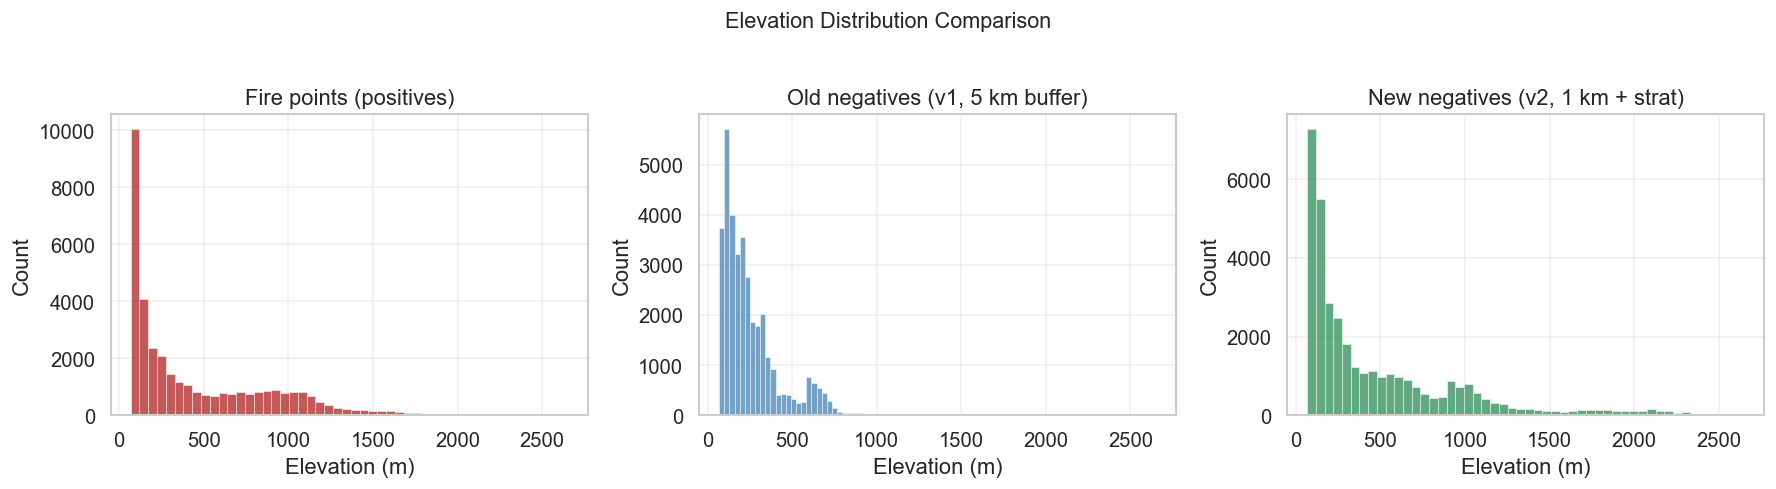

KS test (fire vs new negatives): stat=0.076, p=0.0000
Result: FAIL — distributions still differ significantly


In [8]:
# Load old negatives for comparison
old_samples = gpd.read_file(PROCESSED / 'sample_points.gpkg').to_crs(CRS_WGS84)
old_neg     = old_samples[old_samples.label == 0].copy()

# Read elevation at old negatives
with rasterio.open(dem_path) as src:
    dem_nodata   = src.nodata
    elev_old_neg = np.array([v[0] for v in src.sample(zip(old_neg.lon, old_neg.lat))], dtype=float)
if dem_nodata is not None:
    elev_old_neg[elev_old_neg == dem_nodata] = np.nan
elev_old_neg[elev_old_neg <= -9000] = np.nan
elev_old_neg = elev_old_neg[~np.isnan(elev_old_neg)]

# --- Plot 1: Elevation histograms ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
xmax = valid_elev.max() + 100
for ax, data, label, color in [
    (axes[0], valid_elev,    'Fire points (positives)',          'firebrick'),
    (axes[1], elev_old_neg,  'Old negatives (v1, 5 km buffer)',  'steelblue'),
    (axes[2], neg_elev,      'New negatives (v2, 1 km + strat)', 'seagreen'),
]:
    ax.hist(data, bins=50, color=color, alpha=0.75, edgecolor='white', linewidth=0.4)
    ax.set_xlabel('Elevation (m)')
    ax.set_ylabel('Count')
    ax.set_title(label)
    ax.set_xlim(-50, xmax)
    ax.grid(alpha=0.3)
plt.suptitle('Elevation Distribution Comparison', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS / 'v2_elevation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# KS-test: fire elevations vs new negatives
ks_stat, ks_pval = ks_2samp(valid_elev, neg_elev)
print(f'KS test (fire vs new negatives): stat={ks_stat:.3f}, p={ks_pval:.4f}')
print('Result:', 'PASS (distributions overlap, p > 0.05)' if ks_pval > 0.05
       else 'FAIL — distributions still differ significantly')

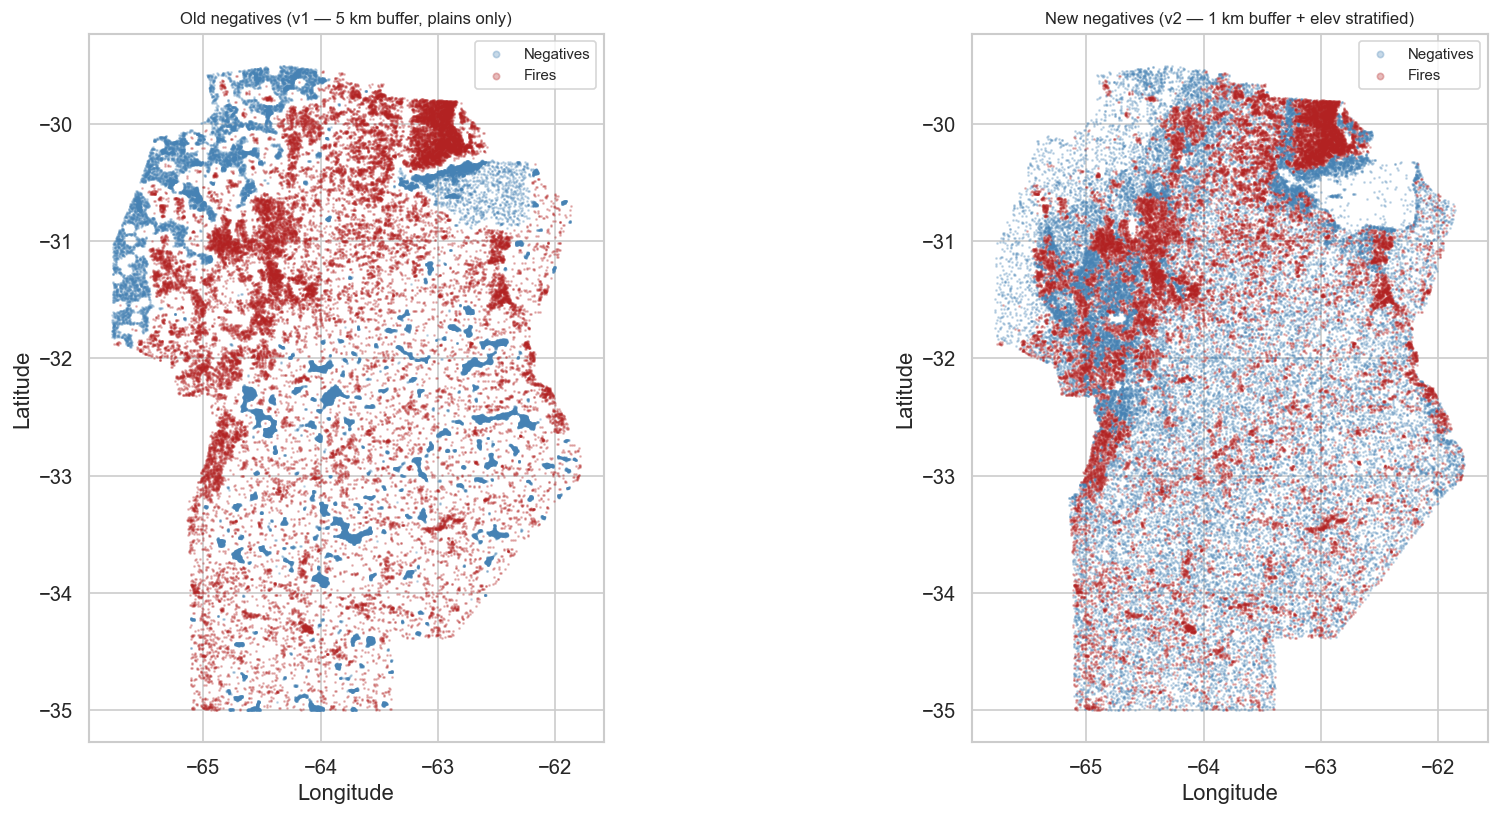

In [9]:
# --- Plot 2: Spatial scatter ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, n_lons, n_lats, title in [
    (axes[0], old_neg.lon.values, old_neg.lat.values,
     'Old negatives (v1 — 5 km buffer, plains only)'),
    (axes[1], neg_lons, neg_lats,
     'New negatives (v2 — 1 km buffer + elev stratified)'),
]:
    ax.scatter(n_lons, n_lats, s=0.4, alpha=0.3, c='steelblue', label='Negatives')
    ax.scatter(pos_gdf.lon, pos_gdf.lat, s=0.4, alpha=0.3, c='firebrick', label='Fires')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(title, fontsize=10)
    ax.legend(markerscale=6, fontsize=9)
    ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(OUTPUTS / 'v2_spatial_scatter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Build GeoDataFrame & Save `sample_points_v2.gpkg`

In [10]:
# Add land cover to positive samples
with rasterio.open(lc_path) as src:
    pos_lc = np.array([v[0] for v in src.sample(zip(pos_gdf.lon, pos_gdf.lat))], dtype=int)
pos_gdf['land_cover_class'] = pos_lc

# Build negative GeoDataFrame
neg_gdf = gpd.GeoDataFrame(
    {
        'label'           : np.zeros(len(neg_lons), dtype=int),
        'lat'             : neg_lats,
        'lon'             : neg_lons,
        'land_cover_class': neg_lc.astype(int),
        'date'            : pd.NaT,
        'month'           : pd.array([9] * len(neg_lons), dtype='Int64'),
    },
    geometry=gpd.points_from_xy(neg_lons, neg_lats),
    crs=CRS_WGS84,
)

# Combine, shuffle, save
combined_v2 = gpd.GeoDataFrame(
    pd.concat([pos_gdf, neg_gdf], ignore_index=True), crs=CRS_WGS84
)
combined_v2 = combined_v2.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

out_path = PROCESSED / 'sample_points_v2.gpkg'
combined_v2.to_file(out_path, driver='GPKG')

print(f'Saved: {out_path}')
print(f'Total  : {len(combined_v2):,}')
print(f'Fires  : {int(combined_v2.label.sum()):,}')
print(f'No-fire: {int((combined_v2.label == 0).sum()):,}')
print(f'Balance: {combined_v2.label.mean():.3f}')

Saved: /Users/gerardoaboulafia/Library/Mobile Documents/com~apple~CloudDocs/UCA/Documentos/Cuatrimestre 7/Labo III/Wildfires/data/processed/sample_points_v2.gpkg
Total  : 72,296
Fires  : 36,148
No-fire: 36,148
Balance: 0.500


## 8. Feature Extraction → `dataset_v2.csv`

In [11]:
# Import extraction functions from data/processing/extract_features.py
sys.path.insert(0, str(ROOT / 'data' / 'processing'))
import importlib
import extract_features as ef
importlib.reload(ef)

samples_v2 = combined_v2.copy()
lons_v2    = samples_v2['lon'].values
lats_v2    = samples_v2['lat'].values

print('=' * 60)
print('Feature Extraction — v2 sample points')
print('=' * 60)

# 1. Raster features
print('\n[1/4] Raster features...')
raster_df = ef.extract_raster_features(lons_v2, lats_v2)

# 2. Aggregate soil depth layers
print('\n[2/4] Aggregating soil depths...')
raster_df = ef.aggregate_soil_depths(raster_df)

# 3. OSM distances (uses cached files in data/raw/osm/)
print('\n[3/4] OSM vector distances (cached)...')
osm_vectors = ef.get_osm_vectors(boundary_poly, bbox)
osm_df      = ef.compute_osm_distances(lons_v2, lats_v2, osm_vectors)

# 4. Temporal features
print('\n[4/4] Temporal features...')
months_v2 = samples_v2['month'].astype('Int64').reset_index(drop=True)
temp_df   = ef.compute_temporal_features(months_v2)

# Assemble
print('\nAssembling dataset_v2...')
dataset_v2 = pd.concat([
    samples_v2[['lat', 'lon', 'label', 'month', 'land_cover_class']].reset_index(drop=True),
    raster_df.drop(columns=['land_cover_class'], errors='ignore').reset_index(drop=True),
    osm_df.reset_index(drop=True),
    temp_df.reset_index(drop=True),
], axis=1)

# Use LC from raster extraction (authoritative)
if 'land_cover_class' in raster_df.columns:
    dataset_v2['land_cover_class'] = raster_df['land_cover_class'].values

out_path = PROCESSED / 'dataset_v2.csv'
dataset_v2.to_csv(out_path, index=False)

print(f'\nSaved: {out_path}')
print(f'Shape: {dataset_v2.shape}')
print(f'Class balance: {dataset_v2.label.mean():.3f}')
null_counts = dataset_v2.isnull().sum()
if null_counts.any():
    print('\nNull counts:')
    for col, n in null_counts[null_counts > 0].items():
        print(f'  {col}: {n}')

Feature Extraction — v2 sample points

[1/4] Raster features...


  elevation                     :     0 NaN / 72,296 total


  slope                         :     0 NaN / 72,296 total


  aspect_cos                    :     0 NaN / 72,296 total


  twi                           :     0 NaN / 72,296 total


...

  Densifying roads geometries (500m spacing)...


  Building roads cKDTree (525,094 coords)...
  distance_to_road_km: min=0.00 km, mean=4.87 km, max=41.05 km
  Densifying rivers geometries (500m spacing)...


  Building rivers cKDTree (633,887 coords)...
  distance_to_river_km: min=0.00 km, mean=7.01 km, max=66.47 km
  Building settlements cKDTree (14 coords)...
  distance_to_settlement_km: min=0.09 km, mean=84.21 km, max=210.07 km

[4/4] Temporal features...



Assembling dataset_v2...



Saved: /Users/gerardoaboulafia/Library/Mobile Documents/com~apple~CloudDocs/UCA/Documentos/Cuatrimestre 7/Labo III/Wildfires/data/processed/dataset_v2.csv
Shape: (72296, 24)
Class balance: 0.500

Null counts:
  population_density: 648


## 9. Verification

In [12]:
print('=== RESAMPLING VERIFICATION ===')

# 1. Sample count matches 1:1
assert combined_v2.label.sum() == (combined_v2.label == 0).sum(), 'Imbalanced sample'
print(f'  [OK] Balanced 1:1 — {n_positive:,} fires, {n_positive:,} negatives')

# 2. KS-test: fire vs new-negatives elevation (expect p > 0.05)
ks_stat2, ks_pval2 = ks_2samp(valid_elev, neg_elev)
symbol = 'OK' if ks_pval2 > 0.05 else 'FAIL'
print(f'  [{symbol}] KS-test elevation overlap: stat={ks_stat2:.3f}, p={ks_pval2:.4f} '
      f'(target p > 0.05)')

# 3. Negatives span mountain zone (some elevation > 500m)
neg_high = (neg_elev > 500).sum()
print(f'  [OK] Negatives > 500m elevation: {neg_high:,} ({neg_high/len(neg_elev)*100:.1f}%)')

# 4. Old negatives barely had any > 500m
old_high = (elev_old_neg > 500).sum()
print(f'  [INFO] Old negatives > 500m: {old_high:,} ({old_high/len(elev_old_neg)*100:.1f}%) '
        f'(should be much lower)')

# 5. dataset_v2.csv saved
assert (PROCESSED / 'dataset_v2.csv').exists()
print(f'  [OK] dataset_v2.csv saved ({len(dataset_v2):,} rows)')

print('\nResampling v2 complete. Run 03b_preprocessing_v2.ipynb next.')

=== RESAMPLING VERIFICATION ===
  [OK] Balanced 1:1 — 36,148 fires, 36,148 negatives
  [FAIL] KS-test elevation overlap: stat=0.076, p=0.0000 (target p > 0.05)
  [OK] Negatives > 500m elevation: 12,348 (34.2%)
  [INFO] Old negatives > 500m: 4,145 (11.5%) (should be much lower)
  [OK] dataset_v2.csv saved (72,296 rows)

Resampling v2 complete. Run 03b_preprocessing_v2.ipynb next.
